# Dimensionality Reduction

## PCA

Here is an example of how decrease number of dimensions in $3D$ dataset via singular matrix decomposition:

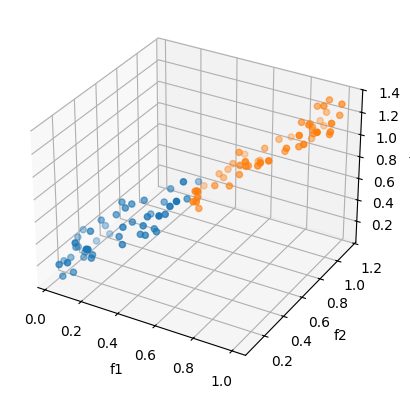

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow

instances = 100

f1 = np.random.rand(instances)
f2 = f1 + np.random.rand(instances) * 0.2
f3 = f2 + np.random.rand(instances) * 0.2

X = np.c_[f1, f2, f3]
y = (f1 > 0.5).astype(np.int8)


fig = plt.figure()
ax = fig.add_subplot(projection="3d")

ax.scatter(X[:, 0][y == 0], X[:, 1][y == 0], X[:, 2][y == 0])
ax.scatter(X[:, 0][y == 1], X[:, 1][y == 1], X[:, 2][y == 1])

ax.set_xlabel('f1')
ax.set_ylabel('f2')
ax.set_zlabel('f3')

plt.show()

In [2]:
def plot_PCA_projection(keep_dims: int, X, y) -> None:
    X_centered = X - X.mean(axis=0)
    U, s, V = np.linalg.svd(X_centered)
    V = V.T

    X_projected = X @ V[:, :keep_dims]

    if keep_dims == 2:
        plt.scatter(X_projected[:, 0][y == 0], X_projected[:, 1][y == 0])
        plt.scatter(X_projected[:, 0][y == 1], X_projected[:, 1][y == 1])
        plt.show()
    elif keep_dims == 1:
        plt.scatter(X_projected[:, 0][y == 0], np.zeros(X_projected[:, 0][y == 0].shape), alpha=0.3)
        plt.scatter(X_projected[:, 0][y == 1], np.zeros(X_projected[:, 0][y == 1].shape), alpha=0.3)
        plt.show()
    else:
        print("Unsupported keep_dims for 3D dataset")

def plot_2D_binary_clf(X, y) -> None:
    plt.scatter(X[:, 0][y == 0], X[:, 1][y == 0])
    plt.scatter(X[:, 0][y == 1], X[:, 1][y == 1])
    plt.show()

def plot_1D_binary_clf(X, y) -> None:
    plt.scatter(X[:, 0][y == 0], np.zeros(X[:, 0][y == 0].shape), alpha=0.3)
    plt.scatter(X[:, 0][y == 1], np.zeros(X[:, 0][y ==1].shape), alpha=0.3)
    plt.show()

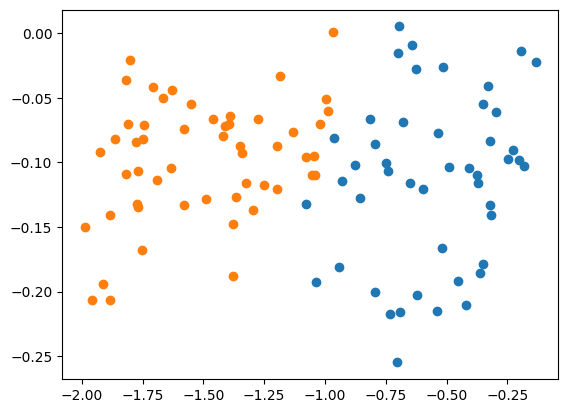

In [3]:
plot_PCA_projection(keep_dims=2, X=X, y=y)

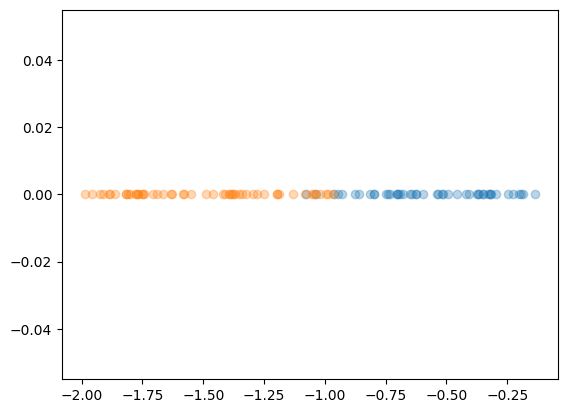

In [4]:
plot_PCA_projection(keep_dims=1, X=X, y=y)

You can also use **SKLearn** class for PCA

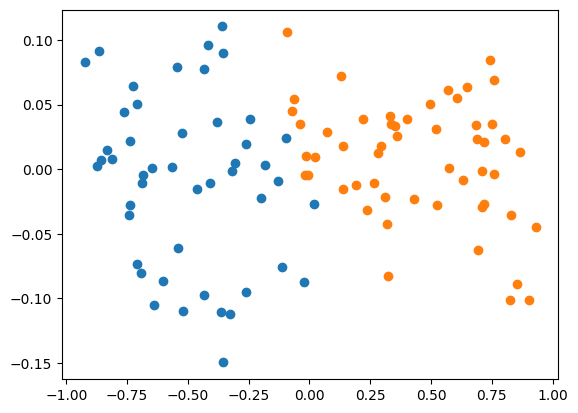

In [5]:
from sklearn.decomposition import PCA

pca2D = PCA(n_components=2)
X_2d = pca2D.fit_transform(X)
plot_2D_binary_clf(X_2d, y)

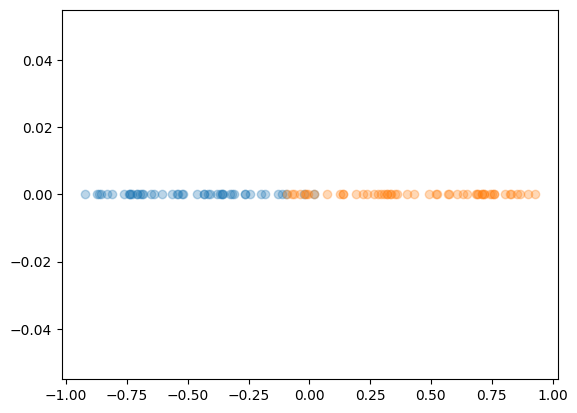

In [6]:
pca1D = PCA(n_components=1)
X_1d = pca1D.fit_transform(X)
plot_1D_binary_clf(X_1d, y)

Explained variance is very useful PCA feature. It allows you to see, what variance has each principal component

In [7]:
pca2D.explained_variance_ratio_

array([0.9858345 , 0.01037928])

The output indicates, than only one feature in the dataset actually gives us variance _(information about the data)_. Other features are just linear combinations via the first feature.

Usually, we choose number of principal components that give us $\approx95\%$ of variance. Here is an example on MNIST dataset

In [8]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", as_frame=True)
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

In [9]:
pca_mnist = PCA()
pca_mnist.fit(X_train)
cumsum = np.cumsum(pca_mnist.explained_variance_ratio_)

d = np.argmax(cumsum >= 0.95) + 1
d

np.int64(154)

Only $154$ features are really important in MNIST! Despite that MNIST contains 784 features...

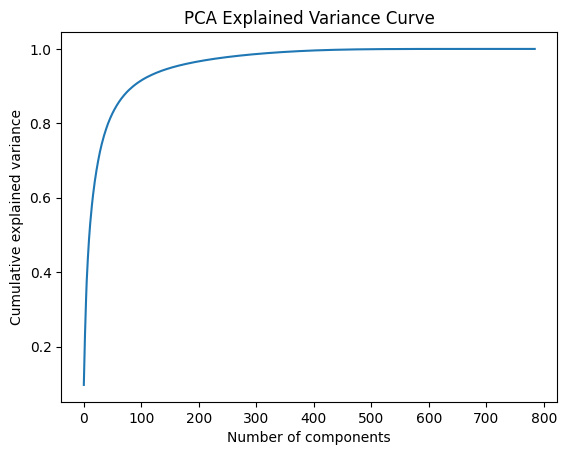

In [10]:
plt.plot(np.linspace(0, cumsum.shape[0], num=cumsum.shape[0]), cumsum)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA Explained Variance Curve")
plt.show()

### Compression

It is possible to use PCA for data compression. Basically, we need to compute inverse matrix that reconstructs data to it's original space with data losses.

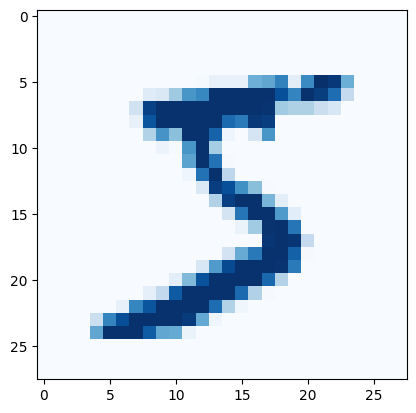

In [11]:
integer = X_train.iloc[0].to_numpy()

plt.imshow(integer.reshape(28, 28), cmap="Blues")
plt.show()

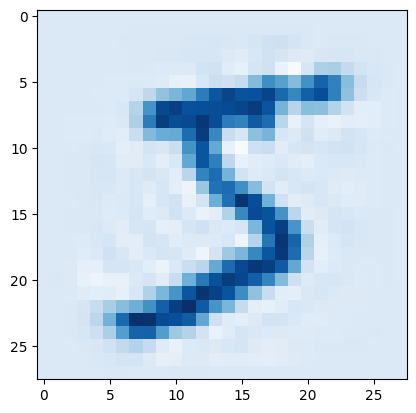

In [12]:
mnist_pca = PCA(n_components=154)

mnist_pca.fit(X_train.to_numpy())
projected_integer = mnist_pca.transform([integer])
compressed_integer = mnist_pca.inverse_transform(projected_integer)

plt.imshow(compressed_integer.reshape(28, 28), cmap="Blues")
plt.show()

The image lost in quality, but it still got $95\%$ of it's information.

Also, you can set `solver` parameter to `full`, `randomized` or `auto` to choose between full and randomized PCA solver.

### Incremental PCA


In [13]:
from pathlib import Path

large_dataset = np.random.rand(5000, 20000)
filename = "big_dataset.mmap"

if not Path(filename).exists():
    mmap = np.memmap(filename, dtype=np.float32, mode="write", shape=large_dataset.shape)
    mmap[:] = large_dataset
    mmap.flush()

In [14]:
from sklearn.decomposition import IncrementalPCA

mmap = np.memmap(filename, dtype=np.float32, mode="readonly", shape=large_dataset.shape)
batch_size = int(mmap.shape[0] / 100)
incr_pca = IncrementalPCA(batch_size=batch_size)
# incr_pca.fit(large_dataset) may run slow

## Random Projection

When your dataset consists of ambitious amount of feature, hundreds and thousands. PCA Would run very slowly. In than case, you can randomly project your dataset onto optimal dimensions using Johnson Lindenstrauss formula.

In [15]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

m, e = 5_000, 0.1
d = johnson_lindenstrauss_min_dim(n_samples=m, eps=e)
d

np.int64(7300)

Now, we can create random projection matrix, and randomly project our dataset onto it.

In [16]:
n = 20_000
rand_proj_matrix = np.random.rand(n, d) / np.sqrt(n)

X = np.random.rand(m, n)
X_rand_proj = X @ rand_proj_matrix
X_rand_proj.shape

(5000, 7300)

Data itself and start number of dimensions are not used at all! Also, you can use SKLearn class, that would return same results as above.

In [17]:
from sklearn.random_projection import GaussianRandomProjection

rand_proj = GaussianRandomProjection(eps=0.1)
X_rand_proj = rand_proj.fit_transform(X)
print(X_rand_proj.shape)

(5000, 7300)


And, if you want to return dimensionality _(it won't retrieve lost data)_, you can compute inverse matrix. As matrix determinant could be zero or it's shape won't we recangular, we need to compute pseudo-inverse matrix.

In [18]:
# May run really slowly
# rand_proj_inv = np.linalg.pinv(rand_proj.components_)
# X_retrieved = X_rand_proj @ rand_proj_inv.T
# X_retrieved.shape

## LLE

LLE is a nonlinear dimensionality reduction technique. It doesn't rely on projection, it's a manifold learning technique.

Let's look at the example of unrolling the swiss roll via LLE

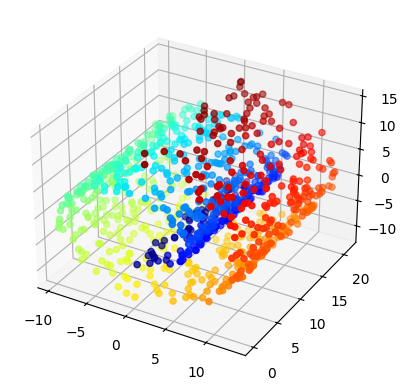

In [19]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import LocallyLinearEmbedding

X_swiss, t_swiss = make_swiss_roll(noise=0.2, n_samples=1000)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_swiss[:, 0], X_swiss[:, 1], X_swiss[:, 2], c=t_swiss, cmap='jet')
plt.show()

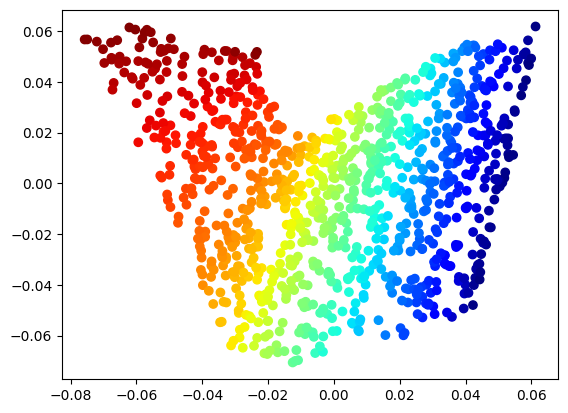

In [20]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
X_swiss_unrolled = lle.fit_transform(X_swiss)

plt.scatter(X_swiss_unrolled[:, 0], X_swiss_unrolled[:, 1], c=t_swiss, cmap='jet')
plt.show()

# Exercises

1. What are the main motivations for reducing a dataset’s dimensionality? What are the main drawbacks?

> As dataset's dimensions incrementing, distances between instances getting bigger and bigger. And number of instances that is needed to evenly fill space grows exponentially. That's why usually we need to reduce dimensionality in complex datasets, like images, and to be able to visualize dataset in 3D. Main drawbacks are: high computational complexity _(due to big matrices multiplication, SVD, inverting matrices for compression)_, data loss in some particular cases.

2. What is the curse if dimensionality?

> It's term, that explains how distances between dots in some space getting bigger as numbers of dimensions getting bigger. E.g. in $3D$ unit cude, average distance between two random dots is $\approx 0.66$, but in $1000D$ cube, the distance is approximately $\approx 406$. And it's getting harder to evenly fill dataset's space, because needed number of instances grows exponentially. In that case, models would extrapolate, instead of interpolating.

3. Once a dataset’s dimensionality has been reduced, is it possible to reverse the operation? If so, how? If not, why?

> Kind of... But with data losses. Usually dimensionality reduction is being executed using projection matrices. If we expand these matrices, so their shape would be rectangular. Their determinant would be $0$. Because we compress original dimensionality to some hyperplane. So we can't traditionally compute inverse matrix to cancel changes. But, we can use pseudo inverse to return back original dimensionality with data losses.


4. Can PCA be used to reduce the dimensionality of a highly nonlinear dataset?

> No, PCA wouldn't work great in that case, because it just searches for a new basis vector in original space to make the best projection keeping variance. For non-linear datasets you can use LLE.

5. Suppose you perform PCA on a $1,000$-dimensional dataset, setting the explained variance ratio to $95\%$. How many dimensions will the resulting dataset have?

> New dataset will have as many dimensions as amount of principal components which collective explained variance sums up to $0.95$. There is no some constant answer, as in random projection.

6. In what cases would you use vanilla PCA, Incremental PCA, Randomized PCA, or Randomized Projection?

> Incremental PCA: if my machine can't hold full dataset in RAM
> Randomized PCA: if my dataset is huge, because PCA has cube computational complexity
> PCA: If none of issue from above met and my dataset isn't highly non-linear
> Randomized Projection: if dataset is really huge and can't fit into Randomized PCA

7. How can you evaluate the performance of a dimensionality reduction algorithm on your dataset?

> If generalizes at close level and its training time is lower - dimensionality reduction algorithm performed well.

8. Does it make any sense to chain two different dimensionality reduction algorithms?

> Yes, for example you can firstly use PCA to remove noise, and then LLE or t-SNE for visualizing in $3D$.

9. Load the MNIST dataset (introduced in Chapter 3) and split it into a training set
and a test set (take the first 60,000 instances for training, and the remaining
10,000 for testing). Train a Random Forest classifier on the dataset and time how
long it takes, then evaluate the resulting model on the test set. Next, use PCA to
reduce the dataset’s dimensionality, with an explained variance ratio of 95%.
Train a new Random Forest classifier on the reduced dataset and see how long it
takes. Was training much faster? Next, evaluate the classifier on the test set. How
does it compare to the previous classifier?

Fetch MNIST dataset

In [21]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1, as_frame=False)

Split data

In [22]:
X = mnist.data
y = mnist.target

X_train, y_train = X[:60000], y[:60000]
X_test, y_test = X[60000:], y[60000:]

Train regular RandomForestClassifier

In [23]:
from sklearn.ensemble import RandomForestClassifier
import time

start = time.time()

ran_for_clf = RandomForestClassifier()
ran_for_clf.fit(X_train, y_train)

end = time.time()

end - start

112.43438982963562

Alright, it took 1 minute to train classifier, let's see how it performs and try to reduce dimensionality

In [24]:
from sklearn.metrics import accuracy_score

y_pred = ran_for_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9695

In [25]:
pca = PCA(n_components=0.95)
pca.fit(X_train)
X_train_proj = pca.fit_transform(X_train)
X_test_proj = pca.transform(X_test)

Now, we can try to train another classifier and we will se whether dimensionality reduction helped us with this classifier

In [26]:
start = time.time()
ran_for_clf = RandomForestClassifier()
ran_for_clf.fit(X_train_proj, y_train)
end = time.time()

end - start

240.26785492897034

Wow! It took 3x times longer to train. Let's see model's performance on test set

In [27]:
y_pred = ran_for_clf.predict(X_test_proj)
accuracy_score(y_test, y_pred)

0.9493

As expected, it dropped a little.

PCA won't always help you to reduce training time.

10. Use t-SNE to reduce the MNIST dataset down to two dimensions and plot the
result using Matplotlib. You can use a scatterplot using 10 different colors to rep resent each image’s target class. Alternatively, you can replace each dot in the
scatterplot with the corresponding instance’s class (a digit from 0 to 9), or even
plot scaled-down versions of the digit images themselves (if you plot all digits,
the visualization will be too cluttered, so you should either draw a random sample or plot an instance only if no other instance has already been plotted at a
close distance). You should get a nice visualization with well-separated clusters of
digits. Try using other dimensionality reduction algorithms such as PCA, LLE, or
MDS and compare the resulting visualizations.

In [28]:
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data
y = mnist.target

In [29]:
from sklearn.manifold import TSNE, MDS

tsne = TSNE()
X_tsne = tsne.fit_transform(X[:10000])
y_tsne = y_train[:10000]

In [30]:
def plot_2d_mnist(X, y, method: str):
    for i in np.unique(y):
        plt.scatter(X[:, 0][i == y], X[:, 1][i == y], marker="v", label=str(i), alpha=0.5)

    plt.title(f"2D Representation of MNIST Dataset via {method}")
    plt.legend()
    plt.show()

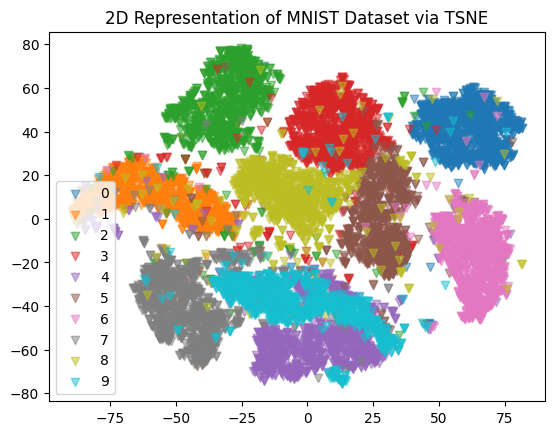

In [31]:
plot_2d_mnist(X_tsne, y_tsne, "TSNE")

C:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


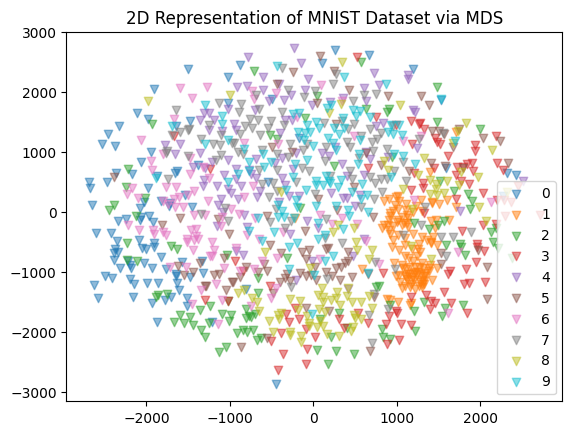

In [32]:
mds = MDS()
X_mds = mds.fit_transform(X[:1000])
y_mds = y_train[:1000]

plot_2d_mnist(X_mds, y_mds, "MDS")

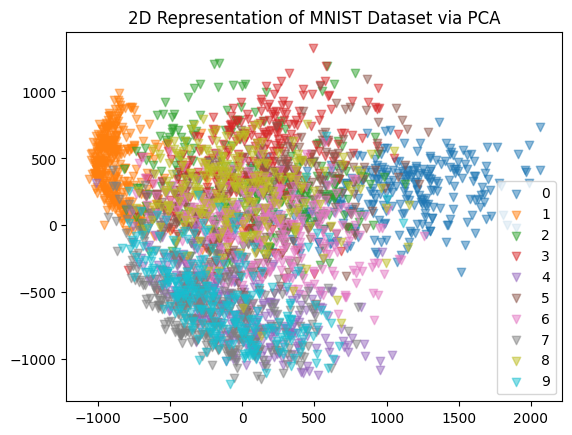

In [33]:
mds = PCA(n_components=2)
X_pca = mds.fit_transform(X[:3000])
y_pca = y_train[:3000]

plot_2d_mnist(X_pca, y_pca, "PCA")

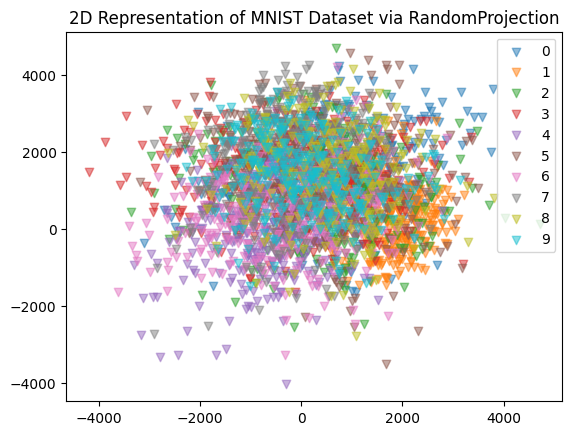

In [34]:
mds = GaussianRandomProjection(n_components=2)
X_ran_proj = mds.fit_transform(X[:3000])
y_ran_proj = y_train[:3000]

plot_2d_mnist(X_ran_proj, y_ran_proj, "RandomProjection")